# 特徵值與特徵向量:從直觀到因素分析的完整教材

> **適用對象**:高中以上、想真正搞懂「特徵值在因素分析裡到底在幹嘛」的學生與教師。
>
> **設計原則**:每一章都用「**白話說明 → 數學推導 → 數值案例 → 可執行程式驗證**」四段式呈現。所有程式以 `numpy` 為主,打開即可逐格 (cell) 執行。

---

## 學習地圖(本教材的主軸)

整份教材會反覆走同一條路。先把它記在心裡,後面每一章都是它的展開:

$$
\underbrace{\text{矩陣 } A}_{\text{變形機器}}
\;\xrightarrow{\;\det(A-\lambda I)=0\;}\;
\underbrace{\text{特徵值 } \lambda}_{\text{伸縮倍數 / 構面重要性}}
\;\xrightarrow{\;(A-\lambda I)\vec v=0\;}\;
\underbrace{\text{特徵向量 } \vec v}_{\text{不轉向的方向 / 構面樣貌}}
\;\xrightarrow{\;\text{負荷量}=\sqrt{\lambda}\,\vec e\;}\;
\underbrace{\text{因素負荷量}}_{\text{每題歸哪組}}
$$

| 章節 | 主題 | 你會學到 |
|---|---|---|
| 第 0 章 | 環境與字型設定 | 讓圖表能正常顯示中文 |
| 第 1 章 | 直觀理解 | 特徵值/特徵向量是什麼(變形機器比喻) |
| 第 2 章 | 手算特徵值 | $\det(A-\lambda I)=0$ 的推導與計算 |
| 第 3 章 | 橋接因素分析 | 相關矩陣、特徵值的兩個關鍵性質 |
| 第 4 章 | 手算範例(2→3→4 題) | 由淺入深,徹底點出特徵值的角色 |
| 第 5 章 | 完整實作 | 咖啡店滿意度問卷,從原始資料跑到構面表 |
| 第 6 章 | 總整理 | 一張表看穿特徵值在每一步的作用 |
| 第 7 章 | 練習題 | 自我檢測 + 解答 |

---
## 第 0 章　環境與字型設定

先載入套件,並設定中文字型(讓圖表的中文不會變成方框 □)。這段程式碼會自動尋找系統中可用的中文字型;若你在自己的電腦上執行,它也會嘗試常見的中文字型名稱。

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=4, suppress=True)   # 數字印漂亮一點
pd.set_option("display.precision", 4)

def use_cjk_font():
    '''自動挑一個可用的中文字型給 matplotlib;找不到就回傳 None。'''
    candidates = ["Noto Sans CJK TC", "Noto Sans CJK SC", "Noto Sans TC",
                  "Microsoft JhengHei", "Microsoft YaHei", "PingFang TC",
                  "Heiti TC", "SimHei", "Arial Unicode MS", "WenQuanYi Zen Hei"]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            matplotlib.rcParams["font.family"] = name
            matplotlib.rcParams["axes.unicode_minus"] = False
            return name
    # 在常見路徑直接註冊 Noto CJK
    import glob
    for fp in glob.glob("/usr/share/fonts/**/NotoSansCJK*.ttc", recursive=True):
        try:
            fm.fontManager.addfont(fp)
            matplotlib.rcParams["font.family"] = "Noto Sans CJK TC"
            matplotlib.rcParams["axes.unicode_minus"] = False
            return "Noto Sans CJK TC"
        except Exception:
            pass
    matplotlib.rcParams["axes.unicode_minus"] = False
    return None

font_used = use_cjk_font()
print("使用字型:", font_used if font_used else "(找不到中文字型,圖表中文可能顯示為方框)")
print("numpy 版本:", np.__version__)

使用字型: Heiti TC
numpy 版本: 2.4.6


---
## 第 1 章　直觀理解:特徵值是什麼?

### 1-1　白話說明:矩陣是一台「變形機器」

把一個矩陣 $A$ 想成一台**變形機器**。你丟一個箭頭(向量 $\vec v$)進去,它會把箭頭**轉向、拉長或壓短**,吐出一個新箭頭 $A\vec v$。

- 大多數箭頭丟進去後,**方向會改變**(本來指東北,出來可能偏東)。
- 但有一些**特別的箭頭**:丟進去後**方向完全不變**,只是被拉長或縮短。

> **特徵向量 (eigenvector)**:方向不變的那種特別箭頭。
> **特徵值 (eigenvalue)**:它被拉長 / 縮短的倍數。

### 1-2　數學定義

「丟進機器後方向不變、只被拉 $\lambda$ 倍」寫成式子就是:

$$\boxed{A\vec v = \lambda \vec v}\qquad (\vec v \neq \vec 0)$$

- 左邊 $A\vec v$:箭頭丟進機器後的結果。
- 右邊 $\lambda \vec v$:原箭頭單純被拉長 $\lambda$ 倍。
- 兩邊相等 $\Rightarrow$ 方向沒變,只是長度變 $\lambda$ 倍。

### 1-3　數值案例

取一台「橫向拉 2 倍、縱向拉 3 倍」的機器:

$$A=\begin{bmatrix}2&0\\0&3\end{bmatrix}$$

- $\vec v=(1,0)\Rightarrow A\vec v=(2,0)=2\,(1,0)$ → 方向不變,$\lambda=2$。
- $\vec v=(0,1)\Rightarrow A\vec v=(0,3)=3\,(0,1)$ → 方向不變,$\lambda=3$。
- $\vec v=(1,1)\Rightarrow A\vec v=(2,3)$ → 方向歪掉,**不是**特徵向量。

下面用程式把這三個箭頭「丟進機器前後」畫出來,你會親眼看到誰轉向、誰沒轉向。

/var/folders/2n/b4n8x33168nc85xp47c9mcv80000gn/T/ipykernel_8265/1964409831.py:20: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  same_dir = np.allclose(np.cross(v, Av), 0)   # 外積=0 代表共線(方向相同)
/var/folders/2n/b4n8x33168nc85xp47c9mcv80000gn/T/ipykernel_8265/1964409831.py:24: UserWarning: Glyph 10004 (\N{HEAVY CHECK MARK}) missing from font(s) Heiti TC.
  plt.tight_layout(); plt.show()
/var/folders/2n/b4n8x33168nc85xp47c9mcv80000gn/T/ipykernel_8265/1964409831.py:24: UserWarning: Glyph 10008 (\N{HEAVY BALLOT X}) missing from font(s) Heiti TC.
  plt.tight_layout(); plt.show()
/Users/chohsunlu/miniconda3/envs/machinelearning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10004 (\N{HEAVY CHECK MARK}) missing from font(s) Heiti TC.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chohsunlu/miniconda3/envs/machinelearning/lib/python3.11/site-packages/IPython/core/pylabt

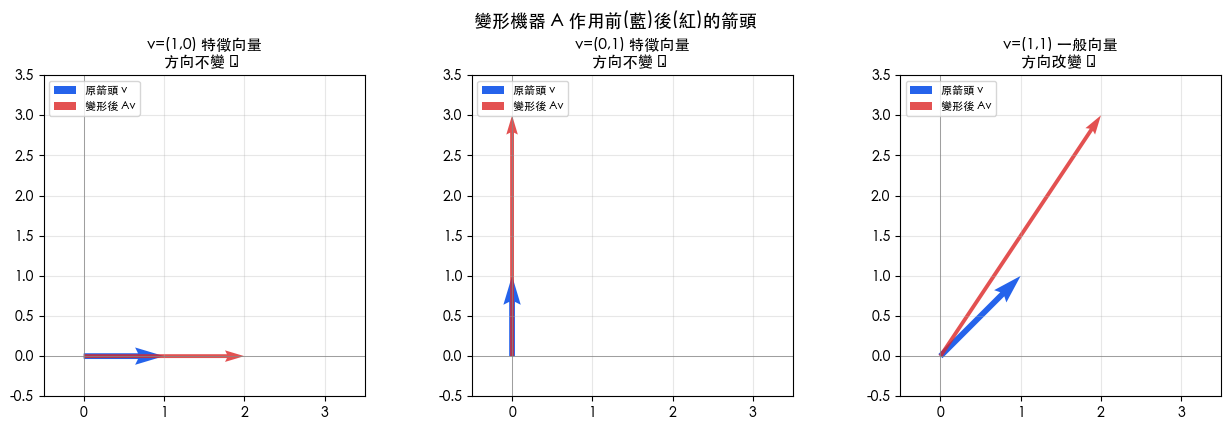

In [2]:
A = np.array([[2., 0.],
              [0., 3.]])

vectors = {
    "v=(1,0) 特徵向量": np.array([1., 0.]),
    "v=(0,1) 特徵向量": np.array([0., 1.]),
    "v=(1,1) 一般向量": np.array([1., 1.]),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (label, v) in zip(axes, vectors.items()):
    Av = A @ v
    ax.quiver(0, 0, v[0], v[1], angles="xy", scale_units="xy", scale=1,
              color="#2563eb", width=0.018, label="原箭頭 v")
    ax.quiver(0, 0, Av[0], Av[1], angles="xy", scale_units="xy", scale=1,
              color="#dc2626", width=0.012, alpha=0.8, label="變形後 Av")
    ax.set_xlim(-0.5, 3.5); ax.set_ylim(-0.5, 3.5)
    ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
    ax.set_aspect("equal"); ax.grid(alpha=0.3)
    same_dir = np.allclose(np.cross(v, Av), 0)   # 外積=0 代表共線(方向相同)
    ax.set_title(f"{label}\n{'方向不變 ✔' if same_dir else '方向改變 ✘'}", fontsize=11)
    ax.legend(fontsize=8, loc="upper left")
plt.suptitle("變形機器 A 作用前(藍)後(紅)的箭頭", fontsize=13)
plt.tight_layout(); plt.show()

---
## 第 2 章　手算特徵值:$\det(A-\lambda I)=0$

### 2-1　推導這把「鑰匙」

從定義 $A\vec v=\lambda\vec v$ 出發,把右邊移到左邊:

$$A\vec v-\lambda\vec v=\vec 0 \;\Longrightarrow\; (A-\lambda I)\vec v=\vec 0$$

($I$ 是單位矩陣,作用是把純量 $\lambda$ 變成可以和矩陣相減的形式。)

這是一個齊次方程式。我們要找的是**非零**的 $\vec v$。線性代數有個關鍵定理:

> 矩陣 $M$ 乘上某個非零向量會得到零向量 $\iff$ $M$ 不可逆 $\iff \det(M)=0$。

所以「存在非零特徵向量」這件事,等價於:

$$\boxed{\det(A-\lambda I)=0}$$

這個方程式叫**特徵方程式 (characteristic equation)**,解出來的 $\lambda$ 就是特徵值。

### 2-2　數值案例:$A=\begin{bmatrix}2&1\\1&2\end{bmatrix}$

**Step 1** 寫出 $A-\lambda I$(對角線各減 $\lambda$):
$$A-\lambda I=\begin{bmatrix}2-\lambda&1\\1&2-\lambda\end{bmatrix}$$

**Step 2** 算行列式(2×2:主對角相乘 − 副對角相乘):
$$(2-\lambda)^2-(1)(1)=0$$

**Step 3** 解方程式:
$$(2-\lambda)^2=1 \Rightarrow 2-\lambda=\pm1 \Rightarrow \lambda_1=3,\;\lambda_2=1$$

**Step 4** 代回求特徵向量:
- $\lambda=3$:解 $(A-3I)\vec v=0$ 得 $x=y$,特徵向量 $(1,1)$。
- $\lambda=1$:解 $(A-I)\vec v=0$ 得 $x=-y$,特徵向量 $(1,-1)$。

下面用程式驗證手算結果,並把符號推導也用 `sympy` 印出來。

In [3]:
A = np.array([[2., 1.],
              [1., 2.]])

# --- 數值解:np.linalg.eig 直接算特徵值與特徵向量 ---
eigvals, eigvecs = np.linalg.eig(A)
order = np.argsort(eigvals)[::-1]          # 由大到小排序
eigvals, eigvecs = eigvals[order], eigvecs[:, order]

print("特徵值 λ =", eigvals)               # 預期 [3, 1]
print("特徵向量(每一行 column 是一個):\n", eigvecs)

print("\n--- 驗證 A v = λ v ---")
for i in range(2):
    v = eigvecs[:, i]
    print(f"λ={eigvals[i]:.0f}:  A v = {A @ v},   λ v = {eigvals[i]*v}")

特徵值 λ = [3. 1.]
特徵向量(每一行 column 是一個):
 [[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]

--- 驗證 A v = λ v ---
λ=3:  A v = [2.1213 2.1213],   λ v = [2.1213 2.1213]
λ=1:  A v = [-0.7071  0.7071],   λ v = [-0.7071  0.7071]


In [4]:
# --- 符號解:把特徵方程式 det(A - λI)=0 真的列出來 ---
import sympy as sp
lam = sp.symbols("lambda")
As = sp.Matrix([[2, 1], [1, 2]])
char_poly = (As - lam*sp.eye(2)).det()
print("特徵方程式 det(A - λI) =", sp.expand(char_poly), "= 0")
print("解得 λ =", sp.solve(char_poly, lam))
print("\nsympy 直接給的特徵值與特徵向量:")
for val, mult, vecs in As.eigenvects():
    print(f"  λ={val},  特徵向量={[list(v) for v in vecs]}")

ModuleNotFoundError: No module named 'sympy'

---
## 第 3 章　橋接因素分析:相關矩陣與兩個關鍵性質

### 3-1　從問卷到「相關矩陣機器」

因素分析想解決的問題:**一份問卷的許多題目,背後其實是由少數幾個「看不見的構面」在驅動。** 例如咖啡店問卷的 12 題,背後可能只有「環境、咖啡品質、服務」3 個構面。

關鍵直覺:**量同一件事的題目,彼此分數會高度相關。** 例如「香氣」高的人,「口感」通常也高。

把所有題目兩兩之間的相關係數排成方陣,就是**相關矩陣 $R$**。它就是我們要丟進「特徵值機器」的那台機器。它的特性:

- 對角線全是 1(每題和自己完全相關)。
- 對稱($r_{ij}=r_{ji}$)。
- 同構面的題目之間數字大,跨構面之間數字小 → 矩陣呈現「**結塊**」的樣子。

### 3-2　兩個貫穿全篇的關鍵性質

> **性質 A:特徵值的總和 = 題目數量。**
> 因為相關矩陣對角線都是 1,其和(跡 trace)= 題數,而矩陣的跡恆等於所有特徵值之和。
> $\Rightarrow$ 某構面「解釋了多少比例的資訊」就是 $\dfrac{\lambda}{\text{題數}}$。

> **性質 B:因素負荷量 $=\sqrt{\lambda}\times(\text{單位特徵向量分量})$。**
> 這是把「數學的特徵向量」翻譯成「因素分析的負荷量」的橋。負荷量平方($\text{loading}^2$)就是該題的**共同性 (communality)**,代表這題有多少比例的變化能被該構面解釋。

### 3-3　特徵值在因素分析裡的三大用途

| 用途 | 看什麼 | 判準 |
|---|---|---|
| ① 決定**抽幾個構面** | 有幾個 $\lambda$ 偏大 | **Kaiser 準則**:$\lambda>1$ 才保留 |
| ② 算**解釋變異比例** | $\lambda/\text{題數}$ | 累積到 60%~80% 以上較理想 |
| ③ 算**因素負荷量** | $\sqrt{\lambda}\,\vec e$ | 負荷量最大的那一欄 → 該題歸該組 |

接下來第 4 章,我們就用手算範例把這三大用途一個一個演給你看。

---
## 第 4 章　手算範例(由淺入深)

### 範例一:最簡單的 2 題

兩題(香氣、口感),相關係數 0.8:

$$R=\begin{bmatrix}1&0.8\\0.8&1\end{bmatrix}$$

**手算特徵值**
$$\det(R-\lambda I)=(1-\lambda)^2-0.8^2=0\Rightarrow 1-\lambda=\pm0.8\Rightarrow \lambda_1=1.8,\;\lambda_2=0.2$$

**性質 A 檢查**:$1.8+0.2=2=$ 題數 ✔

**用途①②**:$\lambda_1=1.8$ 解釋 $1.8/2=90\%$,$\lambda_2=0.2$ 只 $10\%$ → 背後只有 **1 個構面**。

**特徵向量**:$\lambda=1.8$ 代回得 $x=y$,單位化 $(0.707,0.707)$。

**用途③ 負荷量(性質 B)**:$\sqrt{1.8}\times0.707=1.342\times0.707=0.949$。兩題都重壓在因素 1,共同性 $=0.949^2=0.90$。

In [ ]:
R1 = np.array([[1.0, 0.8],
               [0.8, 1.0]])

eigvals, eigvecs = np.linalg.eigh(R1)          # eigh:對稱矩陣專用,回傳已排序(由小到大)
idx = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]

print("特徵值:", eigvals, " | 總和 =", eigvals.sum(), "(= 題數 2,驗證性質A)")
print("解釋比例:", np.round(eigvals/2*100, 1), "%")

# 取第 1 個構面算負荷量(性質 B)
lam1, e1 = eigvals[0], eigvecs[:, 0]
loadings = np.sqrt(lam1) * np.abs(e1)
print("\n第1構面 特徵向量:", np.round(e1, 4))
print("因素負荷量 = √λ × 向量:", np.round(loadings, 4))
print("共同性 (負荷量²):", np.round(loadings**2, 4))

特徵值: [1.8 0.2]  | 總和 = 2.0 (= 題數 2,驗證性質A)
解釋比例: [90. 10.] %

第1構面 特徵向量: [0.7071 0.7071]
因素負荷量 = √λ × 向量: [0.9487 0.9487]
共同性 (負荷量²): [0.9 0.9]


### 範例二:3 題都量同一件事

三題(香氣、口感、新鮮度)兩兩相關都是 0.7:

$$R=\begin{bmatrix}1&0.7&0.7\\0.7&1&0.7\\0.7&0.7&1\end{bmatrix}$$

這種「每對都同相關 $r$」的矩陣有**手算捷徑**:
$$\lambda_1=1+(n-1)r,\qquad \lambda_2=\cdots=\lambda_n=1-r$$
代 $n=3,\,r=0.7$:$\lambda_1=1+2(0.7)=2.4$,其餘 $=1-0.7=0.3$(重根)。

**性質 A**:$2.4+0.3+0.3=3$ ✔　**Kaiser**:只有 $2.4>1$ → 保留 **1 個構面**,解釋 $2.4/3=80\%$。

**負荷量**:特徵向量 $(1,1,1)$ 單位化 $0.577$,$\sqrt{2.4}\times0.577=0.894$,三題皆然,共同性 $0.8$。

In [ ]:
r = 0.7
R2 = np.full((3, 3), r); np.fill_diagonal(R2, 1.0)
print("相關矩陣 R2:\n", R2)

eigvals, eigvecs = np.linalg.eigh(R2)
idx = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
print("\n特徵值:", np.round(eigvals, 4), " (捷徑預測: 2.4, 0.3, 0.3)")
print("Kaiser 準則 λ>1 的個數 =", int((eigvals > 1).sum()), "→ 抽", int((eigvals > 1).sum()), "個構面")
print("解釋比例:", np.round(eigvals/3*100, 1), "%")

lam1, e1 = eigvals[0], eigvecs[:, 0]
load = np.sqrt(lam1)*np.abs(e1)
print("\n因素負荷量:", np.round(load, 4), " 共同性:", np.round(load**2, 4))

相關矩陣 R2:
 [[1.  0.7 0.7]
 [0.7 1.  0.7]
 [0.7 0.7 1. ]]

特徵值: [2.4 0.3 0.3]  (捷徑預測: 2.4, 0.3, 0.3)
Kaiser 準則 λ>1 的個數 = 1 → 抽 1 個構面
解釋比例: [80. 10. 10.] %

因素負荷量: [0.8944 0.8944 0.8944]  共同性: [0.8 0.8 0.8]


### 範例三:4 題,自動分出「兩個構面」(重點題)

前兩題量「咖啡品質」、後兩題量「店員服務」。資料會呈現**結塊**(同組高、跨組近 0):

$$R=\begin{bmatrix}1&0.8&0&0\\0.8&1&0&0\\0&0&1&0.6\\0&0&0.6&1\end{bmatrix}$$

(真實資料跨組不會剛好 0,這裡設 0 是為了讓你手算得動,觀念完全一樣。)

**手算技巧:分塊矩陣**——左上 2×2 與右下 2×2 互不相干,可各自獨立解,等於把範例一做兩次:

- 左上塊(相關 0.8):$\lambda=1\pm0.8\Rightarrow 1.8,\;0.2$
- 右下塊(相關 0.6):$\lambda=1\pm0.6\Rightarrow 1.6,\;0.4$

排序:$\lambda_1=1.8,\;\lambda_2=1.6,\;\lambda_3=0.4,\;\lambda_4=0.2$。**性質 A**:和 $=4$ ✔

**用途①(最核心)**:**有 2 個 $\lambda>1$ → 抽 2 個構面**,前兩者合計解釋 $45\%+40\%=85\%$。

**用途③ 負荷量**:
- 因素 1:$\sqrt{1.8}\,(0.707,0.707,0,0)=(0.949,0.949,0,0)$
- 因素 2:$\sqrt{1.6}\,(0,0,0.707,0.707)=(0,0,0.894,0.894)$

咖啡題壓因素 1、服務題壓因素 2,乾淨分成兩組。下面用程式驗證並畫**陡坡圖 (Scree Plot)**。

In [ ]:
R3 = np.array([
    [1.0, 0.8, 0.0, 0.0],
    [0.8, 1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.6],
    [0.0, 0.0, 0.6, 1.0],
])
items = ["咖啡題A", "咖啡題B", "服務題C", "服務題D"]

eigvals, eigvecs = np.linalg.eigh(R3)
idx = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
print("特徵值:", np.round(eigvals, 4), " | 總和 =", round(eigvals.sum(), 4))

k = int((eigvals > 1).sum())
print(f"Kaiser 準則:λ>1 共 {k} 個 → 抽 {k} 個構面")
print("各構面解釋比例:", np.round(eigvals/4*100, 1), "%",
      " | 前兩構面累積:", round(eigvals[:k].sum()/4*100, 1), "%")

# 算前 k 個構面的負荷量矩陣:loadings[i,j] = sqrt(λ_j) * e_ij
loadings = eigvecs[:, :k] * np.sqrt(eigvals[:k])
load_df = pd.DataFrame(np.round(loadings, 3),
                       index=items, columns=[f"因素{j+1}" for j in range(k)])
load_df["共同性"] = np.round((loadings**2).sum(axis=1), 3)
print("\n因素負荷量表:")
print(load_df)

特徵值: [1.8 1.6 0.4 0.2]  | 總和 = 4.0
Kaiser 準則:λ>1 共 2 個 → 抽 2 個構面
各構面解釋比例: [45. 40. 10.  5.] %  | 前兩構面累積: 85.0 %

因素負荷量表:
        因素1    因素2  共同性
咖啡題A  0.949  0.000  0.9
咖啡題B  0.949  0.000  0.9
服務題C  0.000  0.894  0.8
服務題D  0.000  0.894  0.8


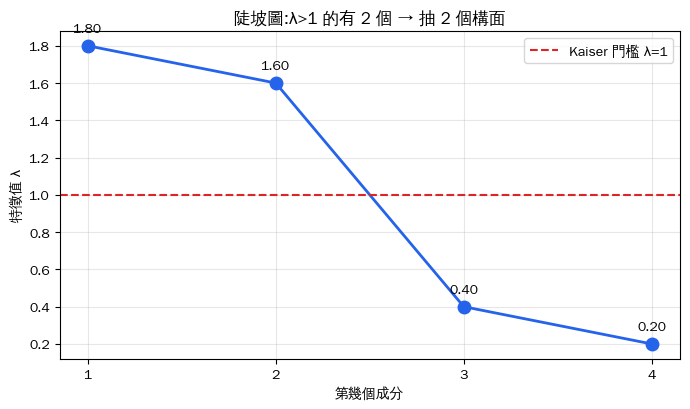

In [ ]:
# 陡坡圖 (Scree Plot):看特徵值在哪裡「手肘急轉彎」
fig, ax = plt.subplots(figsize=(7, 4.2))
x = np.arange(1, len(eigvals)+1)
ax.plot(x, eigvals, "o-", color="#2563eb", lw=2, markersize=9)
ax.axhline(1, color="#dc2626", ls="--", lw=1.5, label="Kaiser 門檻 λ=1")
for xi, yi in zip(x, eigvals):
    ax.annotate(f"{yi:.2f}", (xi, yi), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=10)
ax.set_xticks(x)
ax.set_xlabel("第幾個成分"); ax.set_ylabel("特徵值 λ")
ax.set_title("陡坡圖:λ>1 的有 2 個 → 抽 2 個構面")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 第 5 章　完整實作:咖啡店滿意度問卷

現在把前面所有觀念,套用到一份**完整、貼近真實**的咖啡店問卷上,從「原始作答資料」一路跑到「構面表」。

**情境**:12 題,我們**設計時**讓它由 3 個潛在構面驅動:

- 環境(3 題):裝潢、燈光、座位
- 咖啡品質(4 題):香氣、口感、溫度、新鮮
- 店員服務(5 題):親切、速度、專業、解決、結帳

流程:**模擬資料 → 相關矩陣 → 特徵值 / 陡坡圖 → Kaiser 決定構面數 → 負荷量 →(varimax 旋轉讓歸組更乾淨)→ 解讀**。

In [ ]:
# === Step 1. 模擬一份「背後真的有 3 個構面」的問卷資料 ===
rng = np.random.default_rng(42)
n = 300                                   # 300 位受訪者

# 3 個潛在構面(看不見的真實態度),彼此略相關
F = rng.multivariate_normal(
    mean=[0, 0, 0],
    cov=[[1.0, 0.2, 0.2],
         [0.2, 1.0, 0.2],
         [0.2, 0.2, 1.0]],
    size=n)

cols = ["裝潢", "燈光", "座位",                    # 環境 → F0
        "香氣", "口感", "溫度", "新鮮",            # 咖啡 → F1
        "親切", "速度", "專業", "解決", "結帳"]    # 服務 → F2
belong = [0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 2]      # 每題真正屬於哪個構面

# 每題 = 0.8 × 所屬構面 + 0.2 × 雜訊
data = np.zeros((n, 12))
for j, f in enumerate(belong):
    data[:, j] = 0.8*F[:, f] + 0.6*rng.standard_normal(n)

# 轉成 1~5 分的李克特量表(更像真實問卷)
likert = np.clip(np.round(data*1.2 + 3), 1, 5)
survey = pd.DataFrame(likert, columns=cols)
print("模擬問卷(前 5 位受訪者):")
print(survey.head())
print("\n資料維度:", survey.shape)

模擬問卷(前 5 位受訪者):
    裝潢   燈光   座位   香氣   口感   溫度   新鮮   親切   速度   專業   解決   結帳
0  2.0  1.0  2.0  3.0  3.0  2.0  3.0  5.0  4.0  4.0  4.0  3.0
1  1.0  1.0  1.0  4.0  3.0  5.0  3.0  3.0  4.0  4.0  3.0  1.0
2  3.0  3.0  4.0  3.0  3.0  3.0  4.0  4.0  4.0  2.0  2.0  3.0
3  5.0  4.0  4.0  2.0  3.0  2.0  4.0  3.0  4.0  5.0  4.0  5.0
4  3.0  3.0  4.0  2.0  2.0  2.0  2.0  3.0  5.0  3.0  2.0  4.0

資料維度: (300, 12)


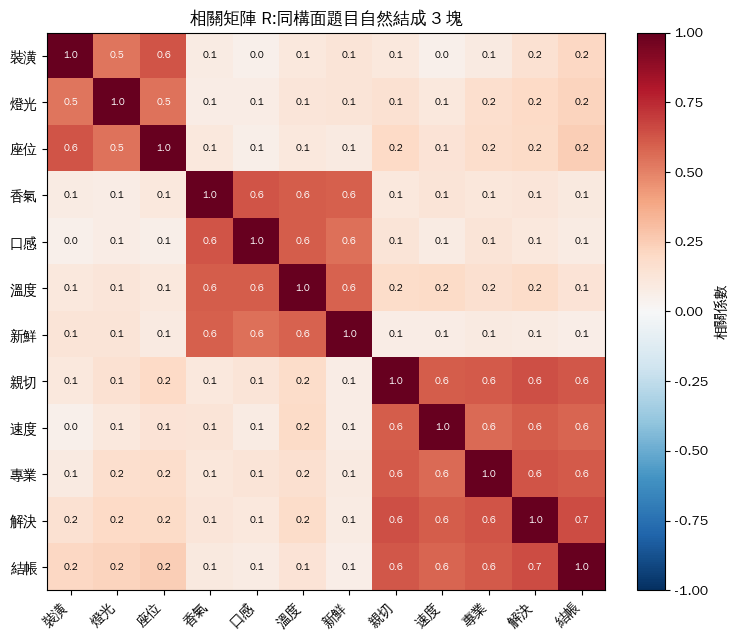

In [ ]:
# === Step 2. 算相關矩陣 R,並畫成熱圖看「結塊」===
R = np.corrcoef(survey.values, rowvar=False)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(R, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(12)); ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticks(range(12)); ax.set_yticklabels(cols)
for i in range(12):
    for j in range(12):
        ax.text(j, i, f"{R[i,j]:.1f}", ha="center", va="center",
                color="white" if abs(R[i,j]) > 0.5 else "black", fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046, label="相關係數")
ax.set_title("相關矩陣 R:同構面題目自然結成 3 塊")
plt.tight_layout(); plt.show()

特徵值(由大到小):
 [4.012 2.511 1.901 0.503 0.463 0.45  0.404 0.393 0.37  0.345 0.337 0.31 ]
總和 = 12.0 (= 題數 12,性質A ✔)

Kaiser 準則:λ>1 的有 3 個 → 抽 3 個構面
各構面解釋比例(%): [33.4 20.9 15.8  4.2  3.9  3.8  3.4  3.3  3.1  2.9  2.8  2.6]
前 3 構面累積解釋: 70.2 %


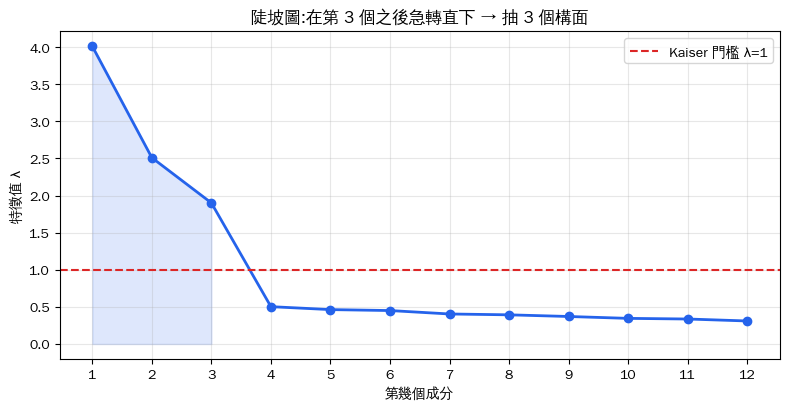

In [ ]:
# === Step 3. 解特徵值 → 陡坡圖 + Kaiser 準則 ===
eigvals, eigvecs = np.linalg.eigh(R)
idx = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]

print("特徵值(由大到小):\n", np.round(eigvals, 3))
print("總和 =", round(eigvals.sum(), 3), "(= 題數 12,性質A ✔)")

k = int((eigvals > 1).sum())
print(f"\nKaiser 準則:λ>1 的有 {k} 個 → 抽 {k} 個構面")
print("各構面解釋比例(%):", np.round(eigvals/12*100, 1))
print(f"前 {k} 構面累積解釋:", round(eigvals[:k].sum()/12*100, 1), "%")

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(1, 13)
ax.plot(x, eigvals, "o-", color="#2563eb", lw=2)
ax.axhline(1, color="#dc2626", ls="--", label="Kaiser 門檻 λ=1")
ax.fill_between(x[:k], 0, eigvals[:k], alpha=0.15, color="#2563eb")
ax.set_xticks(x); ax.set_xlabel("第幾個成分"); ax.set_ylabel("特徵值 λ")
ax.set_title(f"陡坡圖:在第 {k} 個之後急轉直下 → 抽 {k} 個構面")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# === Step 4. 算負荷量,並用 varimax 旋轉讓歸組更乾淨 ===
def varimax(Phi, gamma=1.0, q=50, tol=1e-7):
    '''Kaiser varimax 旋轉:讓每題盡量只在一個因素上有高負荷,方便歸組。'''
    p, k = Phi.shape
    Rrot = np.eye(k)
    d = 0
    for _ in range(q):
        d_old = d
        L = Phi @ Rrot
        diagL = np.diag((L**2).sum(axis=0))
        u, s, vh = np.linalg.svd(Phi.T @ (L**3 - (gamma/p) * L @ diagL))
        Rrot = u @ vh
        d = s.sum()
        if d_old != 0 and d/d_old < 1 + tol:
            break
    return Phi @ Rrot

# 未旋轉負荷量 = sqrt(λ) × 特徵向量
raw_loadings = eigvecs[:, :k] * np.sqrt(eigvals[:k])
rot_loadings = varimax(raw_loadings)

# 讓每個因素的主要負荷為正(美觀),並依絕對值整理成表
for j in range(k):
    if rot_loadings[np.argmax(np.abs(rot_loadings[:, j])), j] < 0:
        rot_loadings[:, j] *= -1

load_df = pd.DataFrame(np.round(rot_loadings, 3),
                       index=cols, columns=[f"因素{j+1}" for j in range(k)])
load_df["共同性"] = np.round((rot_loadings**2).sum(axis=1), 3)
# 標出每題最大負荷落在哪個因素
load_df["歸組"] = [f"因素{np.argmax(np.abs(rot_loadings[i]))+1}" for i in range(12)]
print("旋轉後因素負荷量表(|負荷|>0.5 視為高負荷):\n")
print(load_df)

旋轉後因素負荷量表(|負荷|>0.5 視為高負荷):

      因素1    因素2    因素3    共同性   歸組
裝潢  0.046  0.053  0.862  0.748  因素3
燈光  0.117  0.064  0.801  0.659  因素3
座位  0.142  0.045  0.845  0.736  因素3
香氣  0.061  0.847  0.040  0.723  因素2
口感  0.060  0.836  0.003  0.702  因素2
溫度  0.146  0.827  0.058  0.708  因素2
新鮮  0.009  0.815  0.099  0.674  因素2
親切  0.833  0.075  0.071  0.704  因素1
速度  0.810  0.080 -0.007  0.663  因素1
專業  0.817  0.076  0.068  0.678  因素1
解決  0.841  0.070  0.116  0.726  因素1
結帳  0.817  0.030  0.187  0.704  因素1


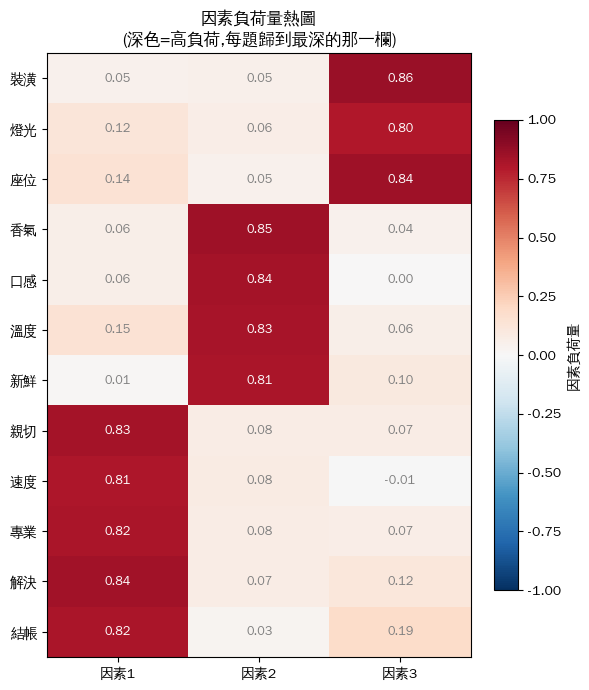

解讀:三塊深色區塊正好對應 環境(裝潢/燈光/座位)、
      咖啡品質(香氣/口感/溫度/新鮮)、服務(親切/速度/專業/解決/結帳)。
      → 特徵值幫我們把 12 題還原成設計時的 3 個構面。


In [ ]:
# === Step 5. 把負荷量畫成熱圖,一眼看出每題歸哪組 ===
fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(rot_loadings, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(k)); ax.set_xticklabels([f"因素{j+1}" for j in range(k)])
ax.set_yticks(range(12)); ax.set_yticklabels(cols)
for i in range(12):
    for j in range(k):
        val = rot_loadings[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="white" if abs(val) > 0.5 else "gray",
                fontweight="bold" if abs(val) > 0.5 else "normal", fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.05, label="因素負荷量")
ax.set_title("因素負荷量熱圖\n(深色=高負荷,每題歸到最深的那一欄)")
plt.tight_layout(); plt.show()

print("解讀:三塊深色區塊正好對應 環境(裝潢/燈光/座位)、")
print("      咖啡品質(香氣/口感/溫度/新鮮)、服務(親切/速度/專業/解決/結帳)。")
print("      → 特徵值幫我們把 12 題還原成設計時的 3 個構面。")

---
## 第 6 章　總整理:特徵值在每一步的角色

| 因素分析的步驟 | 實際在做的數學 | 特徵值 / 特徵向量扮演什麼 |
|---|---|---|
| 看有幾個 $\lambda$ 偏大 | 數 $\lambda>1$ 的個數 | **特徵值大小 = 構面重要性**(Kaiser 準則) |
| 算每個構面解釋多少 | $\lambda/\text{題數}$ | **性質 A**:特徵值總和 = 題數 |
| 看構面長什麼樣 | 解 $(R-\lambda I)\vec v=0$ | **特徵向量分量的正負** = 題目同向/反向關係 |
| 算因素負荷量 | $\sqrt{\lambda}\,\vec e$ | **性質 B**:把特徵值「灌」進負荷量 |
| 每題歸哪一組 | 找負荷量最大的欄 | 負荷量(由特徵值/向量算出)決定題目落點 |

### 一句話收尾

> 因素分析表面上在「幫問卷分構面」,骨子裡做的每一件事——**抽幾個構面、各解釋多少、每題歸哪組**——全都是在解讀那台「相關矩陣機器」的**特徵值與特徵向量**。

從第 1 章的「不轉向的箭頭」,到第 5 章把 12 題咖啡問卷還原成 3 個構面,走的自始至終都是同一條主軸。

---
## 第 7 章　練習題(先自己算,再執行下一格對答案)

**練習 1**　給相關矩陣
$$R=\begin{bmatrix}1&0.5\\0.5&1\end{bmatrix}$$
(a) 手算兩個特徵值。(b) 第一構面解釋多少比例?(c) 它的因素負荷量是多少?

**練習 2**　給「每對相關都 0.6」的 4 題相關矩陣(用捷徑 $\lambda_1=1+(n-1)r$)。
(a) 寫出四個特徵值。(b) 用 Kaiser 準則,應抽幾個構面?(c) 第一構面解釋比例?

**練習 3**　承第 5 章,如果把模擬資料的雜訊調大(把 `0.6*rng.standard_normal` 改成 `1.2*...`),你預期陡坡圖會怎麼變?構面還分得乾淨嗎?(改完重跑第 5 章驗證你的猜測。)

下一格是練習 1、2 的解答與驗算。

In [ ]:
print("===== 練習 1 解答 =====")
R = np.array([[1, 0.5], [0.5, 1.0]])
ev = np.sort(np.linalg.eigvalsh(R))[::-1]
print("(a) 特徵值 λ = 1±0.5 =", ev, "→ 1.5, 0.5")
print("(b) 第一構面解釋比例 = 1.5/2 =", f"{1.5/2*100:.0f}%")
print("(c) 負荷量 = √1.5 × 0.707 =", round(np.sqrt(1.5)*0.7071, 4),
      " 共同性 =", round((np.sqrt(1.5)*0.7071)**2, 3))

print("\n===== 練習 2 解答 =====")
n_item, r = 4, 0.6
lam1 = 1 + (n_item-1)*r
others = 1 - r
print(f"(a) 特徵值:λ1 = 1+3×0.6 = {lam1};其餘三個 = 1-0.6 = {others}")
print(f"    → [{lam1}, {others}, {others}, {others}],總和 = {lam1+3*others} (=題數4 ✔)")
print(f"(b) λ>1 的只有 1 個 → 抽 1 個構面")
print(f"(c) 第一構面解釋 = {lam1}/4 = {lam1/4*100:.0f}%")

# 程式驗證練習2
R2 = np.full((4, 4), 0.6); np.fill_diagonal(R2, 1.0)
print("    程式驗證特徵值:", np.round(np.sort(np.linalg.eigvalsh(R2))[::-1], 3))

===== 練習 1 解答 =====
(a) 特徵值 λ = 1±0.5 = [1.5 0.5] → 1.5, 0.5
(b) 第一構面解釋比例 = 1.5/2 = 75%
(c) 負荷量 = √1.5 × 0.707 = 0.866  共同性 = 0.75

===== 練習 2 解答 =====
(a) 特徵值:λ1 = 1+3×0.6 = 2.8;其餘三個 = 1-0.6 = 0.4
    → [2.8, 0.4, 0.4, 0.4],總和 = 4.0 (=題數4 ✔)
(b) λ>1 的只有 1 個 → 抽 1 個構面
(c) 第一構面解釋 = 2.8/4 = 70%
    程式驗證特徵值: [2.8 0.4 0.4 0.4]


---
### 延伸:想用專業套件一行搞定?

教學時手算最能搞懂原理,但實務分析可用現成套件(需另行安裝):

```python
# pip install factor_analyzer
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# 跑前先檢查資料適不適合做因素分析
kmo_all, kmo_model = calculate_kmo(survey)        # KMO 建議 > 0.6
chi2, p = calculate_bartlett_sphericity(survey)   # Bartlett 球形檢定 p < 0.05

fa = FactorAnalyzer(n_factors=3, rotation="varimax")
fa.fit(survey)
print(fa.get_eigenvalues())   # 特徵值(就是本教材的主角)
print(fa.loadings_)           # 因素負荷量表
```

`factor_analyzer` 內部做的事,和本教材手刻的流程一模一樣:**算相關矩陣 → 解特徵值決定構面數 → 由特徵向量算負荷量 → 旋轉 → 歸組**。你現在已經完全理解它的每一步在幹嘛了。